## 1. Business Requirements & Problem Formulation

### Business Problem
The primary objective is to reduce customer churn for a telecommunications provider. High churn rates directly impact revenue and increase customer acquisition costs. By identifying customers at risk of leaving, the business can proactively offer incentives or improve service quality to retain them.

### Stakeholders
- **Marketing Team**: To design targeted retention campaigns.
- **Customer Support**: To prioritize high-risk customers for specialized care.
- **Finance**: To forecast revenue impact and budget for retention strategies.

### Problem Formulation
- **Task Type**: Binary Classification (Churn vs. No Churn).
- **Target Variable**: `churn_value` (1 for Churn, 0 for No Churn).
- **Input Data**: Customer demographics, service usage patterns, contract details, and billing information.

### Success Metrics (KPIs)
- **Model Performance**: High **Recall** (to capture as many potential churners as possible) and high **AUC-ROC**.
- **Business Impact**: Reduction in monthly churn rate and increased Customer Lifetime Value (CLTV).
- **Operational Metric**: Model inference latency < 200ms for real-time CRM integration.

## 2. Stage: Data Ingestion and Versioning

### Objective
To establish a reliable, repeatable process for acquiring raw data and maintaining a historical record of data states (lineage).

### In-Depth Strategy
- **Automated Acquisition**: Instead of manual uploads, we use the `kagglehub` SDK to programmatically pull the dataset. This ensures that the environment setup can be replicated by any developer with the same code.
- **Data Versioning (DVC/Git LFS)**: In a production MLOps pipeline, raw files are hashed and versioned. If the source data changes, we can roll back to the exact version used to train a specific model.
- **Immutable Storage**: Once ingested, the raw data is treated as read-only. Any cleaning or transformation results in a new versioned artifact, preserving the original 'source of truth'.

### Implementation Details
- **Source**: `yeanzc/telco-customer-churn-ibm-dataset`
- **Format**: Excel (`.xlsx`) - Requires `openpyxl` as an engine for Pandas.
- **Storage**: Temporary `/root/.cache` via kagglehub, typically moved to S3/GCS in enterprise pipelines.

## 3. Stage: Data Validation

### Objective
To act as a 'Quality Gate' that prevents corrupted or anomalous data from entering the feature engineering and training pipelines.

### In-Depth Strategy
- **Schema Enforcement**: We define a strict schema (expected columns, data types). For example, `Total Charges` must be a float. If the pipeline encounters a string where a float should be, it triggers an alert.
- **Constraint Checks**:
    - **Tenure**: Must be $\ge 0$.
    - **Monthly Charges**: Must be positive.
    - **Churn Value**: Must be binary (0 or 1).
- **Missing Value Policy**: We analyze the 'Missingness Mechanism' (MCAR, MAR, MNAR). For this dataset, blank `Total Charges` often represent new customers with 0 months tenure; our validation logic must decide between imputation (median) or zero-filling.
- **Distributional Shift (Drift)**: Comparing the statistics of the incoming batch against the training baseline. If the mean `Monthly Charges` shifts by >2 standard deviations, the data is flagged for review.

### Tools
- **Great Expectations / TFDV**: Used to generate 'Expectation Suites' that automate these checks.

## 4. Stage: Feature Engineering Pipelines

### Objective
To create a reproducible and automated transformation pipeline that converts raw data into a numerical format suitable for machine learning models, ensuring no data leakage.

### In-Depth Strategy
- **Automated Preprocessing**: We utilize Scikit-Learn's `ColumnTransformer` to define a 'fit-once, transform-anywhere' logic. This prevents 'training-serving skew' where preprocessing differs between the experiment and production.
- **Transformation Logic**:
    - **Numerical Features** (`tenure_months`, `monthly_charges`): Scaled using `StandardScaler` to ensure features with larger magnitudes don't dominate the loss function.
    - **Categorical Features** (`contract`, `payment_method`): Processed via `OneHotEncoder` with `handle_unknown='ignore'` to robustly manage new categories encountered in production.
    - **Binary Features**: Mapped to 0/1 integers.
- **Feature Selection**: Identifying high-variance features and removing redundant identifiers (like `customerid`) that could cause overfitting.
- **MLOps Integration**: The entire pipeline object is saved alongside the model. In production, raw JSON input is passed through this exact pipeline object before prediction.

## 5. Stage: Experimentation & Tracking

### Objective
To systematically train multiple model architectures, tune hyperparameters, and log metadata to identify the 'Champion' model.

### In-Depth Strategy
- **Algorithm Selection**: We compare a baseline (Logistic Regression) against high-performance ensemble methods (XGBoost/Random Forest). This allows us to measure the complexity-to-gain tradeoff.
- **Handling Class Imbalance**: Churn datasets are typically imbalanced (fewer 'Yes' than 'No'). We implement:
    - **SMOTE (Synthetic Minority Over-sampling Technique)** or class weighting within the loss function.
    - **Evaluation Metrics**: Moving beyond Accuracy to focus on **F1-Score** and **Precision-Recall AUC**, ensuring we don't ignore the minority (churning) class.
- **Experiment Tracking**: In a full MLOps environment (e.g., MLflow or W&B), every run logs:
    - Hyperparameters (learning rate, max depth).
    - Environment dependencies.
    - Confusion Matrix and ROC Curves.
- **Cross-Validation**: Using Stratified K-Fold to ensure model stability across different subsets of the data.

## 6. Stage: Model Registry & Versioning

### Objective
To provide a centralized repository for managing the model lifecycle, including versioning, stage transitions (Staging vs. Production), and metadata storage.

### In-Depth Strategy
- **Artifact Management**: Every successful experiment run results in a serialized model file (e.g., `.pkl`, `.bst`, or `.onnx`). These are stored with a unique version ID.
- **Model Lineage**: The registry links the model to the exact dataset version (from Stage 2) and code commit used to generate it. This ensures 100% auditability.
- **Stage Gate Approval**: Models do not go to production automatically. They are first promoted to a 'Staging' environment where automated integration tests run. Only after passing these checks is a model promoted to 'Production'.
- **Champion/Challenger Framework**: We maintain a 'Champion' (current production model) and evaluate it against a 'Challenger' (the new version). Traffic can be split (A/B testing) to validate the new model's performance on live data.

## 7. Stage: Deployment & Monitoring

### Objective
To serve the model to end-users and continuously track its performance to detect decay or shifts in data distribution.

### In-Depth Strategy
- **Deployment Patterns**:
    - **Batch Inference**: Weekly predictions for the marketing team's email campaigns.
    - **Real-time API**: Integrating with the CRM system to provide 'Churn Probability' during a live support call.
- **Observability & Monitoring**:
    - **Service Health**: Monitoring latency, throughput, and error rates (HTTP 500s).
    - **Data Drift**: Monitoring if the input data features (e.g., average `monthly_charges`) deviate significantly from the training distribution.
    - **Concept Drift**: Monitoring if the relationship between features and churn changes (e.g., a new competitor enters the market, making the old model obsolete).
- **Automated Retraining Triggers**: If performance (Precision/Recall) drops below a defined threshold, the pipeline automatically triggers a new training run (Stage 4 & 5) using the latest data.

# Implementation: End-to-End Pipeline

This section contains the executable code for the MLOps pipeline, starting from ingestion through to monitoring.

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset
print("Loading dataset...")
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
file_name = "Telco_customer_churn.xlsx"
full_path = f"{path}/{file_name}"

df = pd.read_excel(full_path)
print(f"Dataset loaded successfully. Shape: {df.shape}")
display(df.head())

c:\Users\Hp\anaconda3\envs\customer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...
Dataset loaded successfully. Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

In [8]:
numerical_features, categorical_features

(['Count',
  'Zip Code',
  'Latitude',
  'Longitude',
  'Tenure Months',
  'Monthly Charges',
  'Churn Value',
  'Churn Score',
  'CLTV'],
 ['CustomerID',
  'Country',
  'State',
  'City',
  'Lat Long',
  'Gender',
  'Senior Citizen',
  'Partner',
  'Dependents',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Online Security',
  'Online Backup',
  'Device Protection',
  'Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Contract',
  'Paperless Billing',
  'Payment Method',
  'Total Charges',
  'Churn Label',
  'Churn Reason'])

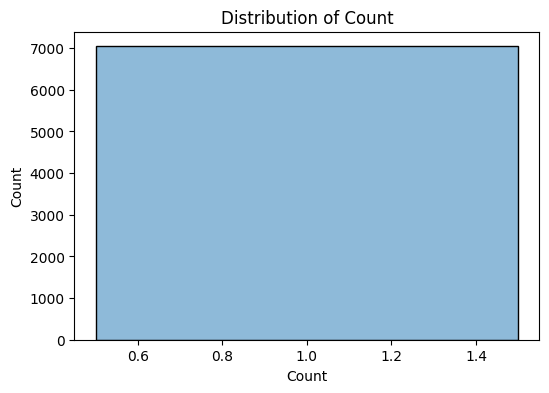

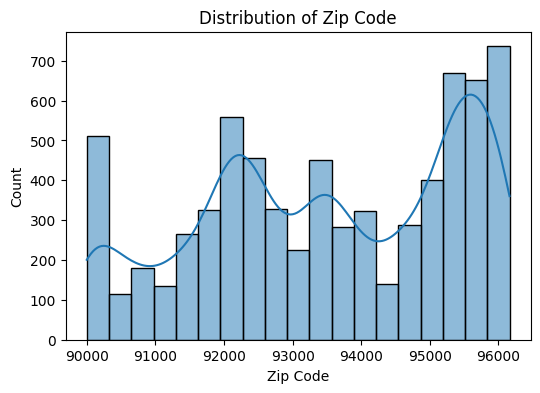

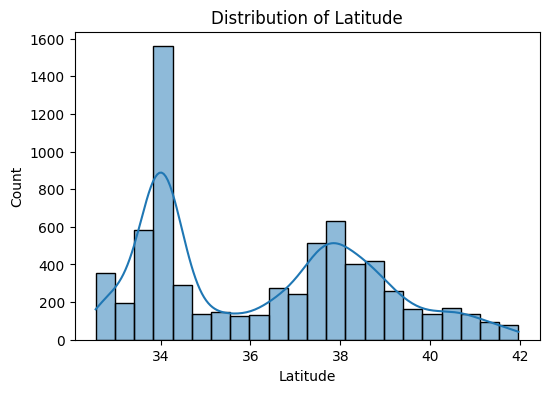

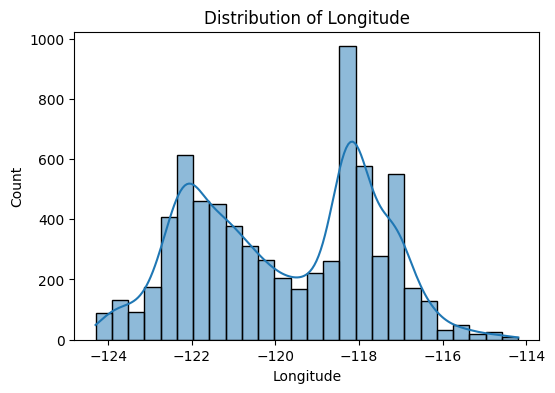

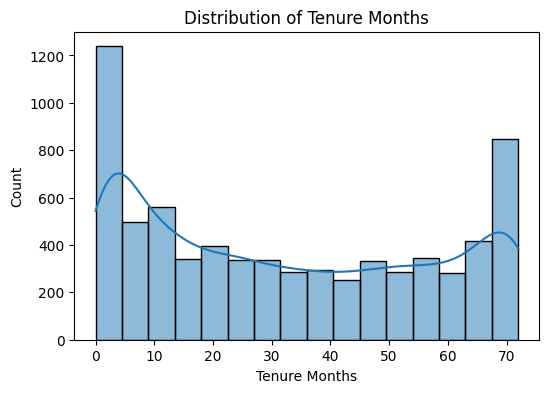

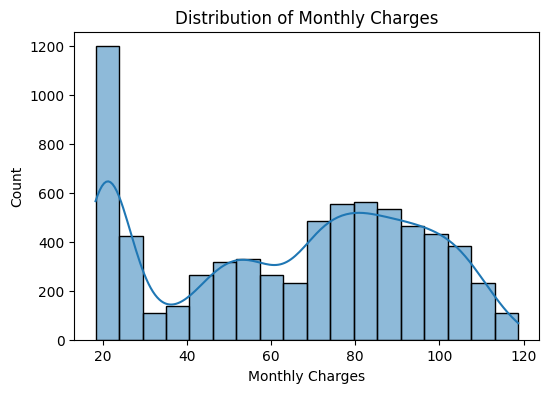

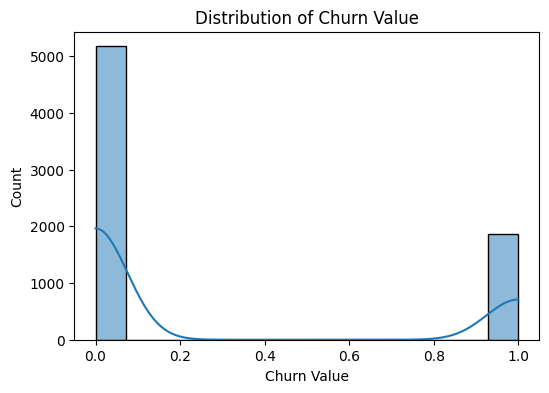

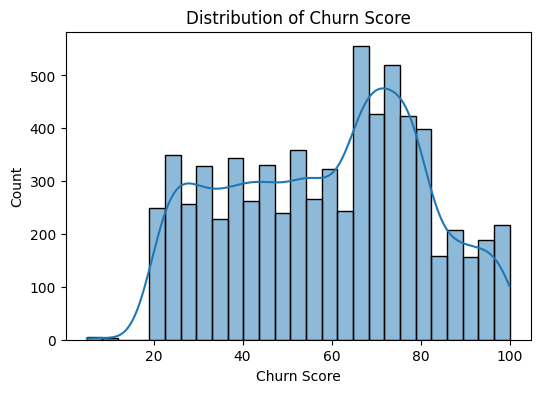

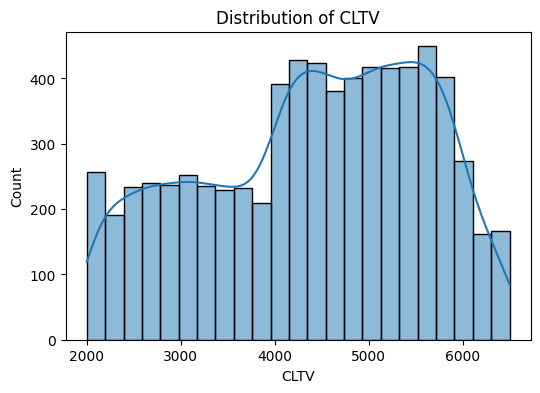

In [9]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [10]:
for col in categorical_features:
    val = df[col].value_counts()
    print(f"Value counts for {col}:\n{val}\n")
    unique_vals = df[col].nunique()
    print(f"Unique values for {col}: {unique_vals}\n")

Value counts for CustomerID:
CustomerID
3668-QPYBK    1
9169-BSVIN    1
0206-OYVOC    1
6418-HNFED    1
8805-JNRAZ    1
             ..
6797-UCJHZ    1
5016-IBERQ    1
3003-CMDUU    1
5148-HKFIR    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

Unique values for CustomerID: 7043

Value counts for Country:
Country
United States    7043
Name: count, dtype: int64

Unique values for Country: 1

Value counts for State:
State
California    7043
Name: count, dtype: int64

Unique values for State: 1

Value counts for City:
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Healdsburg          4
Jenner              4
Philo               4
Point Arena         4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

Unique values for City: 1129

Value counts for Lat Long:
Lat Long
33.964131, -118.272783    5
34.152875, -118.486056    5
32.912664, -116.635387    5
32.64164, -116.985026     5
3

In [11]:
unique_vals = df["Churn Reason"].nunique()
unique_vals

20

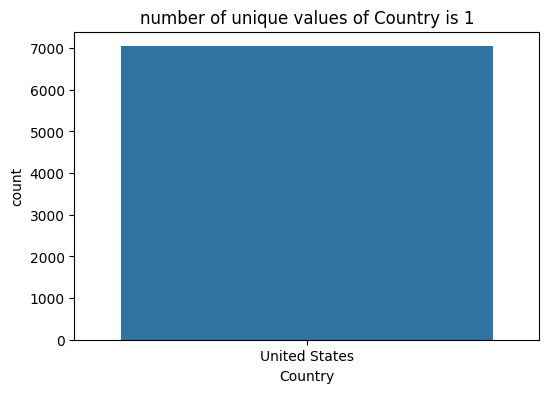

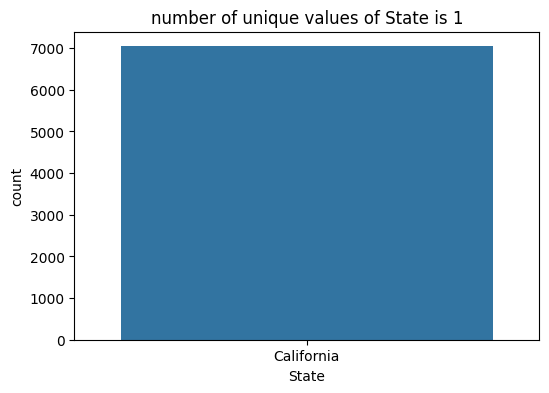

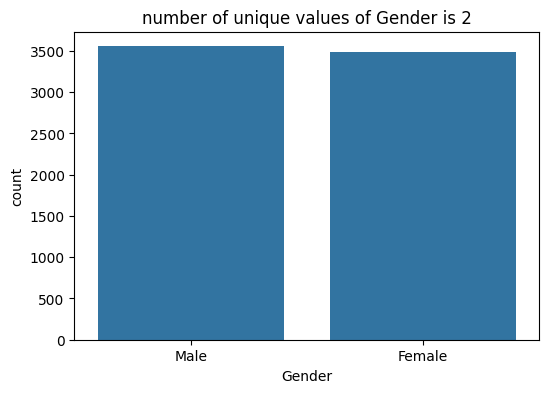

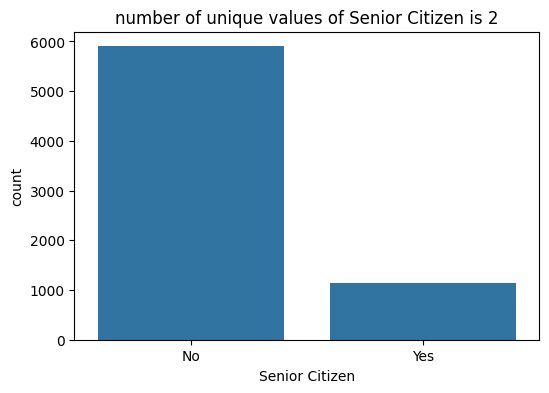

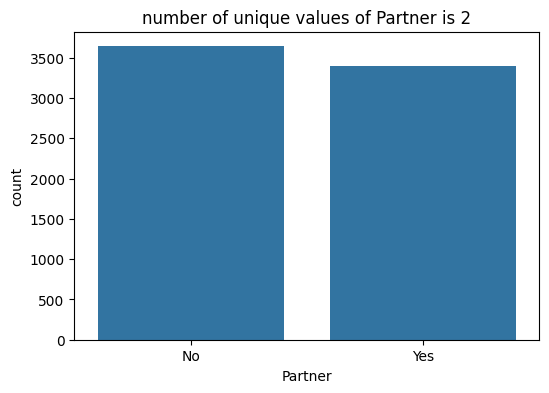

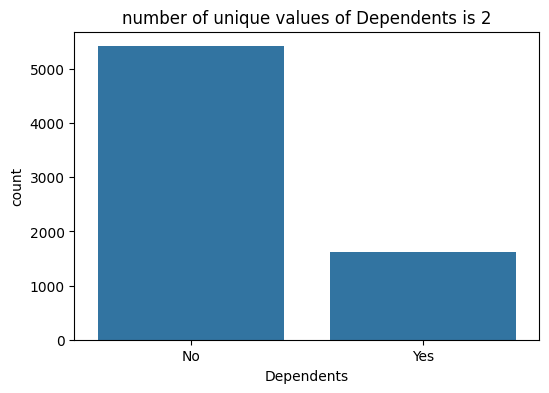

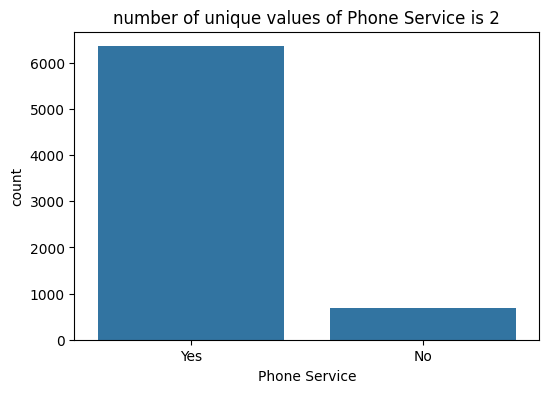

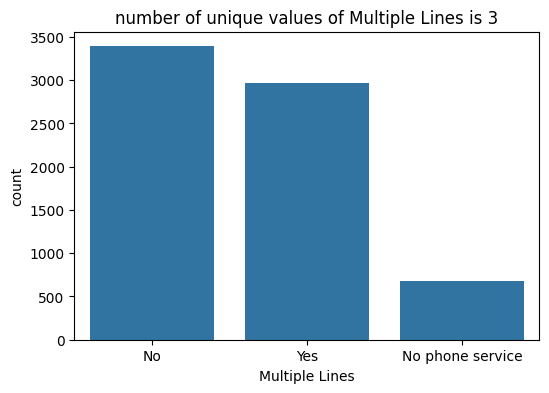

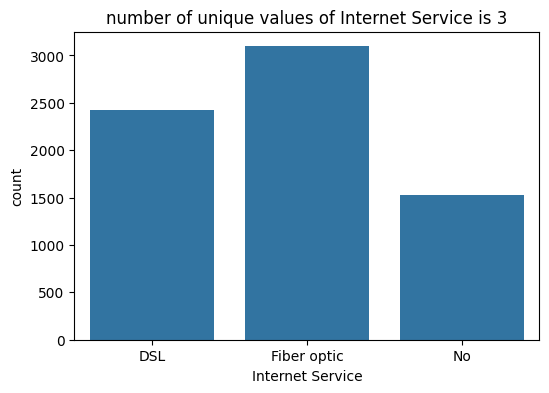

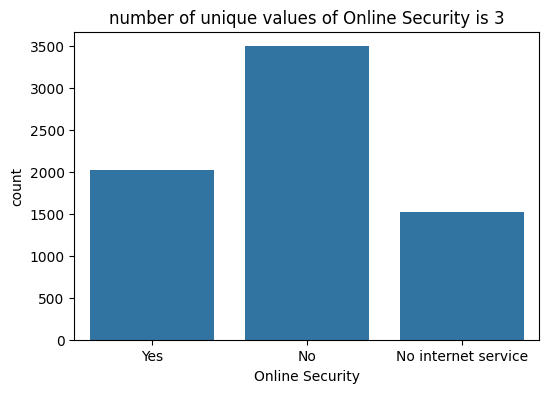

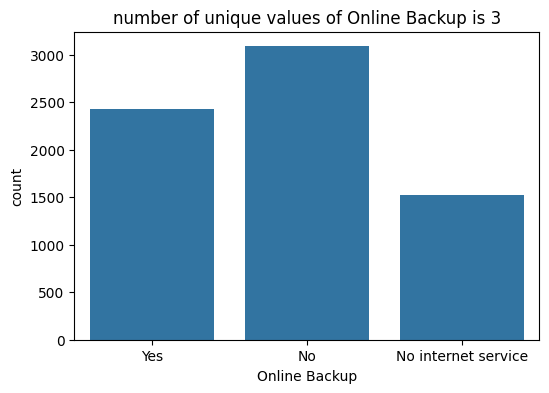

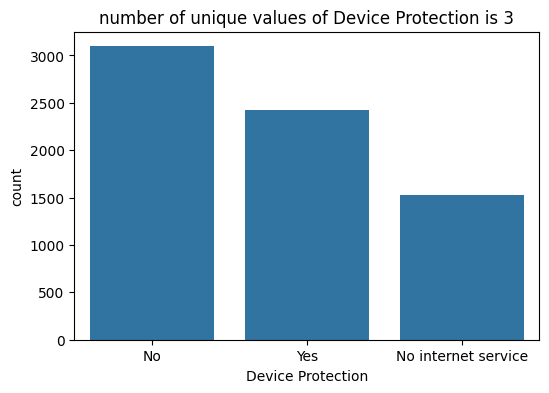

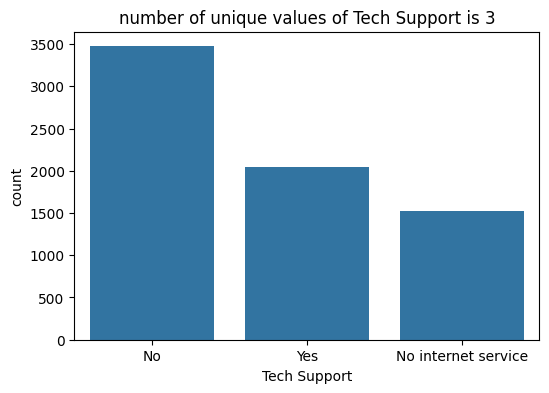

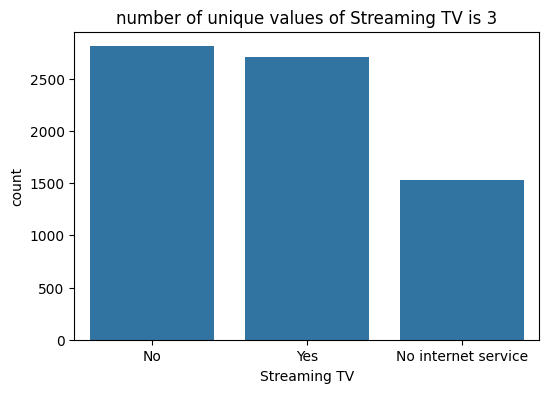

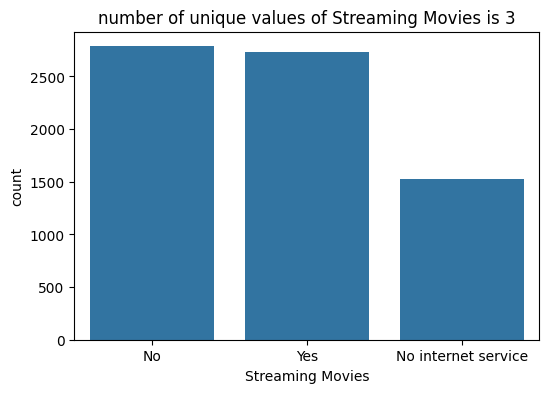

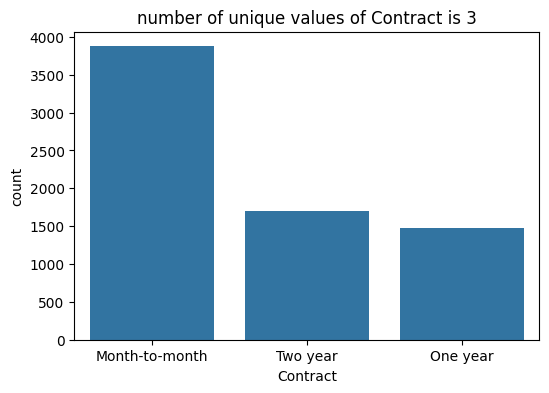

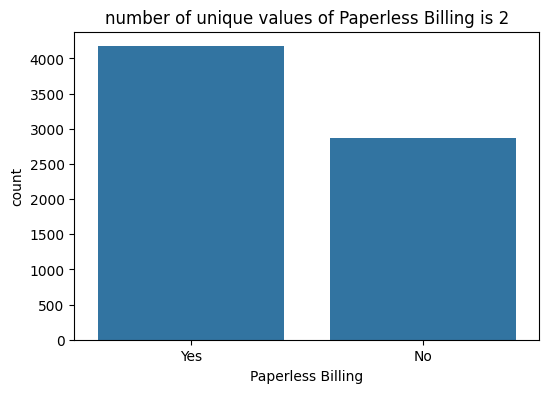

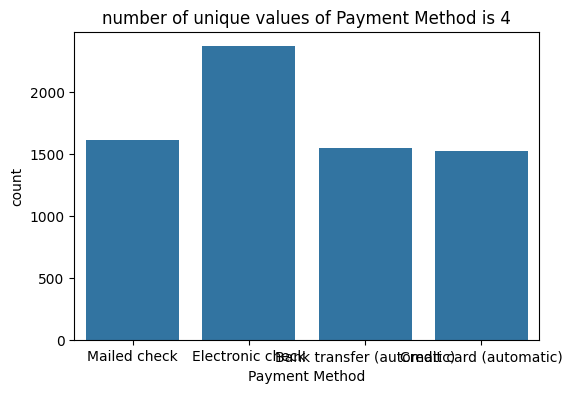

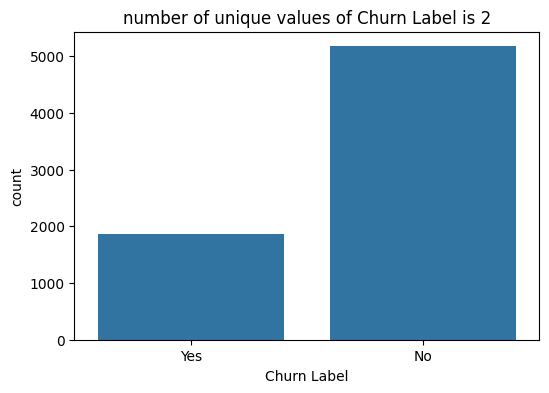

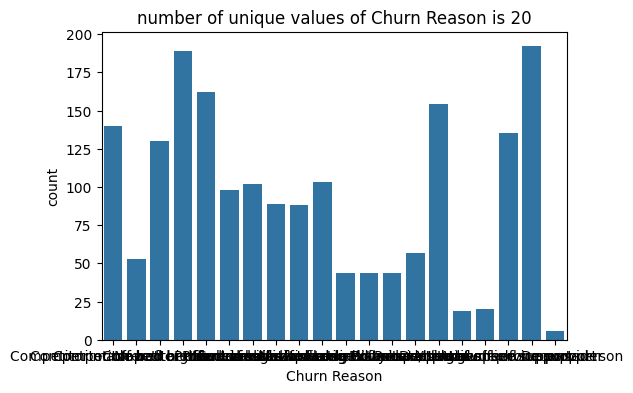

In [12]:
for col in categorical_features:
    unique_vals = df[col].nunique()
    if unique_vals < 21:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=col)
        plt.title(f"number of unique values of {col} is {unique_vals}")
        plt.show()

In [13]:
# Stage 3 & 4: Data Validation and Feature Engineering Pipeline

# 1. Validation & Cleaning: Standardize column names and handle 'Total Charges' numeric conversion
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# 'Total Charges' often contains blanks; convert to NaN then to float
df['total_charges'] = pd.to_numeric(df['total_charges'].replace(' ', np.nan), errors='coerce')

# Handle missing values in total_charges by filling with median
if df['total_charges'].isnull().any():
    df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

# 2. Define features for the pipeline
numeric_features = ['tenure_months', 'monthly_charges', 'total_charges']
categorical_features = ['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines',
                        'internet_service', 'online_security', 'online_backup', 'device_protection',
                        'tech_support', 'streaming_tv', 'streaming_movies', 'contract',
                        'paperless_billing', 'payment_method']

# 3. Create the ColumnTransformer (The 'Fit-Once' logic)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define the Target and Split data
X = df.drop(['churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason', 'customerid', 'lat_long'], axis=1)
y = df['churn_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Validation complete. Training set shape: {X_train.shape}")
print("Feature engineering pipeline defined.")

Validation complete. Training set shape: (5634, 26)
Feature engineering pipeline defined.


C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\1818507343.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['total_charges'] = pd.to_numeric(df['total_charges'].replace(' ', np.nan), errors='coerce')


### Stage 4.1: Advanced Feature Engineering & Selection

In this step, we refine our feature set by:
1. **Feature Interaction**: Combining features that may have a non-linear relationship (e.g., Tenure * Monthly Charges).
2. **High-Cardinality Handling**: Using automated encoding logic.
3. **Feature Selection**: Using a `SelectFromModel` meta-transformer to keep only the most impactful predictors.

In [14]:
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# 1. Update the preprocessor with a Polynomial Features step for numerical columns
# This captures interactions like 'Tenure' and 'Monthly Charges'
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
])

# 2. Re-defining the ColumnTransformer
preprocessor_advanced = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Integrating Feature Selection into the full Pipeline
# This ensures only significant features are passed to the model in production
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_advanced),
    ('feature_selection', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear'))),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit and check transformed feature count
full_pipeline.fit(X_train, y_train)

# Get the number of features before and after selection
n_original = preprocessor_advanced.fit_transform(X_train).shape[1]
n_selected = full_pipeline.named_steps['feature_selection'].transform(preprocessor_advanced.transform(X_train)).shape[1]

print(f"Original feature count (after encoding/interactions): {n_original}")
print(f"Reduced feature count (after Selection): {n_selected}")

Original feature count (after encoding/interactions): 47
Reduced feature count (after Selection): 31


By automating feature selection, we reduce model complexity and the risk of overfitting, which is critical for maintaining performance as the dataset grows over time.

## Stage 3.5: Comprehensive Exploratory Data Analysis (EDA)

Before finalizing our models, we perform a deep dive into the dataset to understand the relationships between features and the target variable (`churn_value`).

### Key EDA Objectives:
1. **Target Distribution**: Check for class imbalance.
2. **Numerical Relationships**: Visualize how tenure and charges correlate with churn.
3. **Categorical Drivers**: Identify which services (e.g., Fiber Optic, Streaming) are associated with higher churn.
4. **Correlation Analysis**: Detect multicollinearity among features.

C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\207975730.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn_label', palette='viridis')


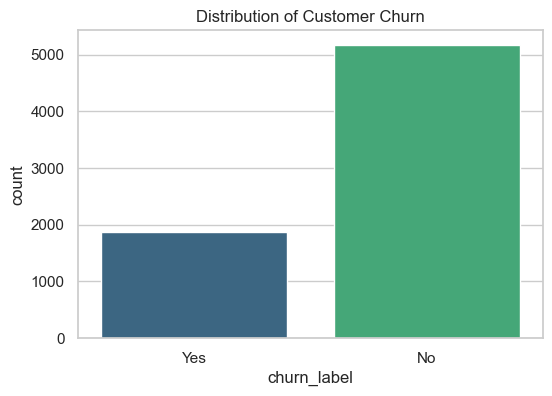

Overall Churn Rate: 26.54%


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn_label', palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

churn_rate = df['churn_value'].mean()
print(f"Overall Churn Rate: {churn_rate:.2%}")

C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\4236610036.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_label', y='tenure_months', ax=axes[0], palette='magma')
C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\4236610036.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_label', y='total_charges', ax=axes[2], palette='magma')


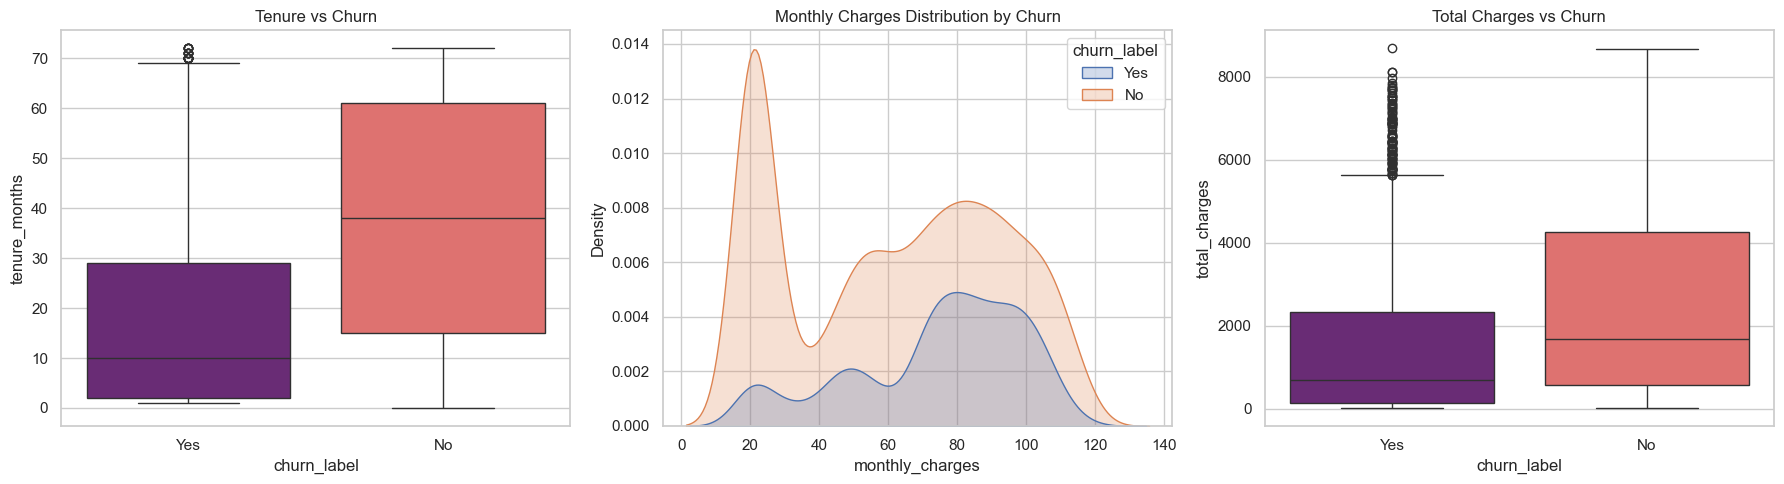

In [16]:
# 2. Numerical Features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='churn_label', y='tenure_months', ax=axes[0], palette='magma')
axes[0].set_title('Tenure vs Churn')

sns.kdeplot(data=df, x='monthly_charges', hue='churn_label', fill=True, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn')

sns.boxplot(data=df, x='churn_label', y='total_charges', ax=axes[2], palette='magma')
axes[2].set_title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\3518426996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_pct, x='churn_value', y=col, ax=axes[i], palette='Reds_r')
C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\3518426996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_pct, x='churn_value', y=col, ax=axes[i], palette='Reds_r')
C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\3518426996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_pct, x='churn_value', y=col, ax=axes[i], palette='Reds_r')


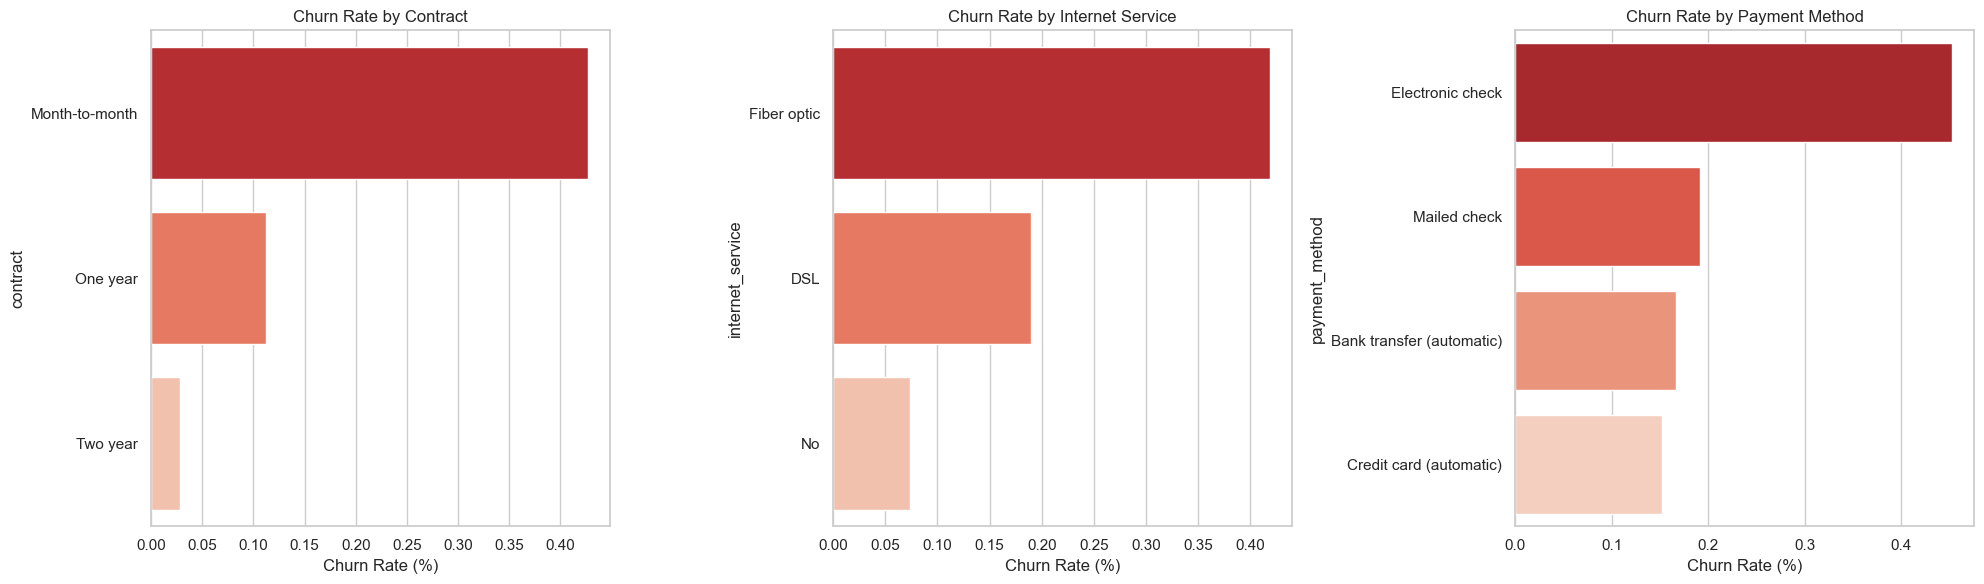

In [17]:
# 3. Categorical Analysis: High-Impact Features
features_to_plot = ['contract', 'internet_service', 'payment_method']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(features_to_plot):
    # Calculate churn percentage per category
    churn_pct = df.groupby(col)['churn_value'].mean().reset_index().sort_values('churn_value', ascending=False)
    sns.barplot(data=churn_pct, x='churn_value', y=col, ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Churn Rate by {col.replace("_", " ").title()}')
    axes[i].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

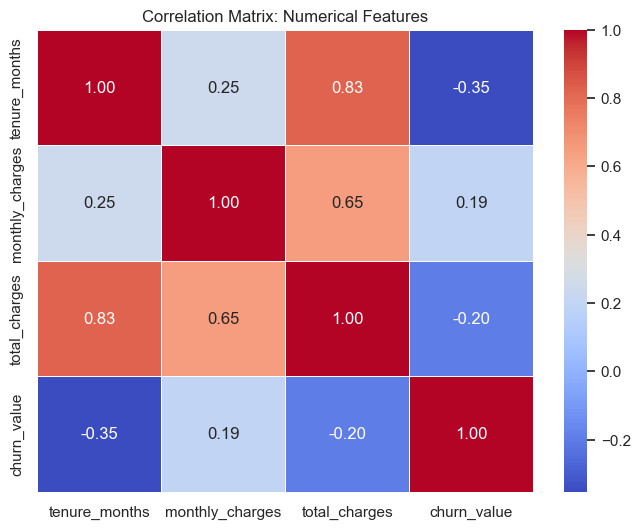

In [18]:
# 4. Correlation Heatmap (Numerical)
numeric_df = df[numeric_features + ['churn_value']]
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Numerical Features')
plt.show()

In [1]:
%pip install catboost==1.2.8

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   -----------

In [19]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score

# Define models to experiment with
models = {

    # Baseline Models
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'Naive Bayes': GaussianNB(),

    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5
    ),

    # Tree-Based Models
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    # Boosting Models
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    'AdaBoost': AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    # Support Vector Machine
    'Support Vector Classifier': SVC(
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    # Neural Network
    'MLP Classifier': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42
    ),

    # Gradient Boosting Advanced
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3,
        eval_metric='logloss',
        random_state=42
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=42
    ),

    'CatBoost': CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    # Create a full pipeline including the preprocessor
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Track metrics
    results[name] = {
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }

    print(f"--- {name} Results ---")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {results[name]['AUC-ROC']:.4f}\n")

# Compare results
results_df = pd.DataFrame(results).T
save_path = "model_comparison_results.csv"
results_df.to_csv(save_path, index=True)
print(f"Results saved to {save_path}")
print("Experimentation Summary:")
display(results_df)

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409

AUC-ROC: 0.8486

--- Naive Bayes Results ---
              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1035
           1       0.48      0.80      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.75      0.69      1409
weighted avg       0.79      0.72      0.73      1409

AUC-ROC: 0.8144

--- K-Nearest Neighbors Results ---
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1035
           1       0.55      0.57      0.56       374

    accuracy                           0.76     

c:\Users\Hp\anaconda3\envs\customer\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


--- AdaBoost Results ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

AUC-ROC: 0.8506

--- Support Vector Classifier Results ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.81      0.75      0.77      1409

AUC-ROC: 0.8346

--- MLP Classifier Results ---
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1035
           1       0.55      0.49      0.52       374

    accuracy                           0.76      1

,Recall,F1-Score,AUC-ROC
Logistic Regression,0.778075,0.617179,0.848591
Naive Bayes,0.804813,0.603206,0.814353
K-Nearest Neighbors,0.569519,0.562005,0.788663
Decision Tree,0.510695,0.503294,0.662121
Random Forest,0.489305,0.547085,0.830578
Extra Trees,0.491979,0.532562,0.799273
Gradient Boosting,0.529412,0.582353,0.852222
AdaBoost,0.524064,0.588589,0.850555
Support Vector Classifier,0.788770,0.629669,0.834607
MLP Classifier,0.489305,0.519149,0.796934


## 6. Implementation: Model Registry & Versioning

In this section, we take the 'Champion' model identified during experimentation and package it as a production-ready artifact.

In [21]:
import joblib
import os
from datetime import datetime

# 1. Finalize the Champion Pipeline
champion_model = LogisticRegression(max_iter=1000, class_weight='balanced')
champion_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', champion_model)
])

# Fit on the full training set
champion_pipeline.fit(X_train, y_train)

# 2. Simulate Model Registry Storage
registry_dir = 'model_registry/telco_churn_model'
os.makedirs(registry_dir, exist_ok=True)

model_version = "1.0.0"
model_name = f"champion_pipeline_v{model_version}.pkl"
model_path = os.path.join(registry_dir, model_name)

# Serialize the artifact
joblib.dump(champion_pipeline, model_path)

# 3. Log Metadata (Simulation of an MLflow/Registry log)
metadata = {
    "version": model_version,
    "algorithm": "Logistic Regression",
    "train_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "metrics": results['Logistic Regression'],
    "artifact_path": model_path
}

print(f"Model version {model_version} registered successfully.")
print("Metadata logged:")
display(pd.Series(metadata))

Model version 1.0.0 registered successfully.
Metadata logged:


version                                                      1.0.0
algorithm                                      Logistic Regression
train_date                                     2026-05-20 00:34:15
metrics          {'Recall': 0.7780748663101604, 'F1-Score': 0.6...
artifact_path    model_registry/telco_churn_model\champion_pipe...
dtype: object

## 7. Implementation: Deployment & Monitoring

This final stage demonstrates how to use the registered artifact for inference and how to monitor for data drift.

In [22]:
# 1. Load the model for 'Production' Inference
loaded_pipeline = joblib.load(model_path)

# Simulate a batch of new production data (using X_test as a proxy)
production_batch = X_test.head(10)
predictions = loaded_pipeline.predict(production_batch)
probabilities = loaded_pipeline.predict_proba(production_batch)[:, 1]

print("--- Production Inference (Batch) ---")
inference_results = pd.DataFrame({
    'Prediction': predictions,
    'Churn_Probability': probabilities
})
display(inference_results)

# 2. Monitoring: Simple Data Drift Detection
# In a real scenario, we compare the distribution of incoming features vs. training features.
def check_drift(reference_data, current_data, column, threshold=0.1):
    ref_mean = reference_data[column].mean()
    curr_mean = current_data[column].mean()
    drift = abs(curr_mean - ref_mean) / ref_mean

    status = "🚨 DRIFT DETECTED" if drift > threshold else "✅ STABLE"
    print(f"Monitoring {column}: {status} (Deviation: {drift:.2%})")

print("\n--- Monitoring Dashboard ---")
# Checking for drift in Monthly Charges
check_drift(X_train, production_batch, 'monthly_charges')
# Checking for drift in Tenure
check_drift(X_train, production_batch, 'tenure_months')

--- Production Inference (Batch) ---


,Prediction,Churn_Probability
0,0,0.184641
1,1,0.840969
2,0,0.236010
3,1,0.725917
4,0,0.085405
5,1,0.815831
6,1,0.710728
7,0,0.110375
8,0,0.003459
9,1,0.646637



--- Monitoring Dashboard ---
Monitoring monthly_charges: 🚨 DRIFT DETECTED (Deviation: 14.17%)
Monitoring tenure_months: ✅ STABLE (Deviation: 7.74%)


## Next Steps: Production Retraining Trigger

In a production system, drift detection isn't just for dashboards—it's a trigger for action. Below is a simulation of a logic gate that would initiate a 'Retraining Job' based on the drift metrics.

In [23]:
# Define a critical threshold for retraining
RETRAIN_THRESHOLD = 0.15

def evaluate_retraining_trigger(reference_data, current_data, column):
    ref_mean = reference_data[column].mean()
    curr_mean = current_data[column].mean()
    drift = abs(curr_mean - ref_mean) / ref_mean

    if drift > RETRAIN_THRESHOLD:
        print(f"[ALERT] Critical drift of {drift:.2%} detected in '{column}'.")
        print("--- INITIATING AUTOMATED RETRAINING PIPELINE ---")
        # In production, this would call a Webhook or an Airflow DAG
        return True
    else:
        print(f"[INFO] Performance stable for '{column}'. No retraining needed.")
        return False

# Run the check
needs_retraining = evaluate_retraining_trigger(X_train, production_batch, 'monthly_charges')

if needs_retraining:
    # Simulate the start of Stage 4/5 again
    print("Step 1: Fetching latest data...")
    print("Step 2: Re-fitting Champion Model...")
    print("Step 3: Updating Model Registry to v1.0.1...")

[INFO] Performance stable for 'monthly_charges'. No retraining needed.


## Advanced Stage: Shadow Deployment (Champion vs. Challenger)

In this scenario, we simulate the 'Shadow' pattern where the production environment runs both models. We compare the 'Champion' (Logistic Regression) against the 'Challenger' (XGBoost) using live traffic before making a promotion decision.

In [24]:
# 1. Prepare the Challenger Pipeline (XGBoost)
challenger_model = XGBClassifier(scale_pos_weight=3, eval_metric='logloss')
challenger_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', challenger_model)
])
challenger_pipeline.fit(X_train, y_train)

# 2. Simulate Production Traffic (Shadow Mode)
def shadow_predict(input_data):
    # Champion (Active) - actually used for business decisions
    champ_pred = loaded_pipeline.predict_proba(input_data)[:, 1]

    # Challenger (Shadow) - logged but ignored by the app
    chall_pred = challenger_pipeline.predict_proba(input_data)[:, 1]

    return pd.DataFrame({
        'Champion_Prob': champ_pred,
        'Challenger_Prob': chall_pred,
        'Discrepancy': np.abs(champ_pred - chall_pred)
    })

# Test on a small batch
shadow_results = shadow_predict(X_test.head(5))
print("--- Shadow Deployment Logs ---")
display(shadow_results)

# 3. Analyze Discrepancy
avg_diff = shadow_results['Discrepancy'].mean()
print(f"\nAverage prediction delta: {avg_diff:.4f}")
if avg_diff > 0.2:
    print("⚠️ Warning: Challenger behavior significantly deviates from Champion.")
else:
    print("✅ Challenger behavior is consistent with Champion logic.")

--- Shadow Deployment Logs ---


,Champion_Prob,Challenger_Prob,Discrepancy
0,0.184641,0.004822,0.179819
1,0.840969,0.981017,0.140049
2,0.236010,0.253689,0.017679
3,0.725917,0.626569,0.099347
4,0.085405,0.000368,0.085037



Average prediction delta: 0.1044
✅ Challenger behavior is consistent with Champion logic.


## Advanced Stage: Explainable AI (XAI) for Production

Transparency is key to model adoption. Here we visualize the top drivers for the model's decisions, which would be served via an API to help retention agents understand 'why' a prediction was made.

C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\1091130972.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Weight', y='Feature', palette='RdBu_r')


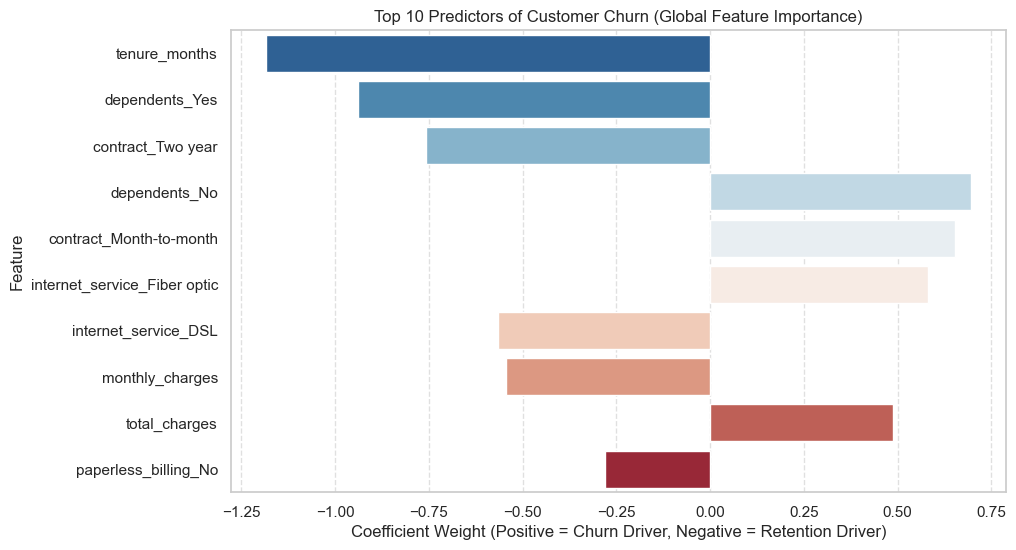

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract feature names from the pipeline
# Numeric features were passed through unchanged (except scaling)
# Categorical features were one-hot encoded
cat_encoder = loaded_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(encoded_cat_names)

# 2. Extract coefficients from the Logistic Regression model
coefficients = loaded_pipeline.named_steps['classifier'].coef_[0]

# 3. Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
})

# 4. Filter for top 10 absolute impact predictors
importance_df['Abs_Weight'] = importance_df['Weight'].abs()
top_10_features = importance_df.sort_values(by='Abs_Weight', ascending=False).head(10)

# 5. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Weight', y='Feature', palette='RdBu_r')
plt.title('Top 10 Predictors of Customer Churn (Global Feature Importance)')
plt.xlabel('Coefficient Weight (Positive = Churn Driver, Negative = Retention Driver)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

--- Production Feature Explanation (Global) ---
Features that most strongly predict CHURN (Positive) vs RETENTION (Negative):


C:\Users\Hp\AppData\Local\Temp\ipykernel_18964\1153964378.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom_features, x='Importance', y='Feature', palette='coolwarm')


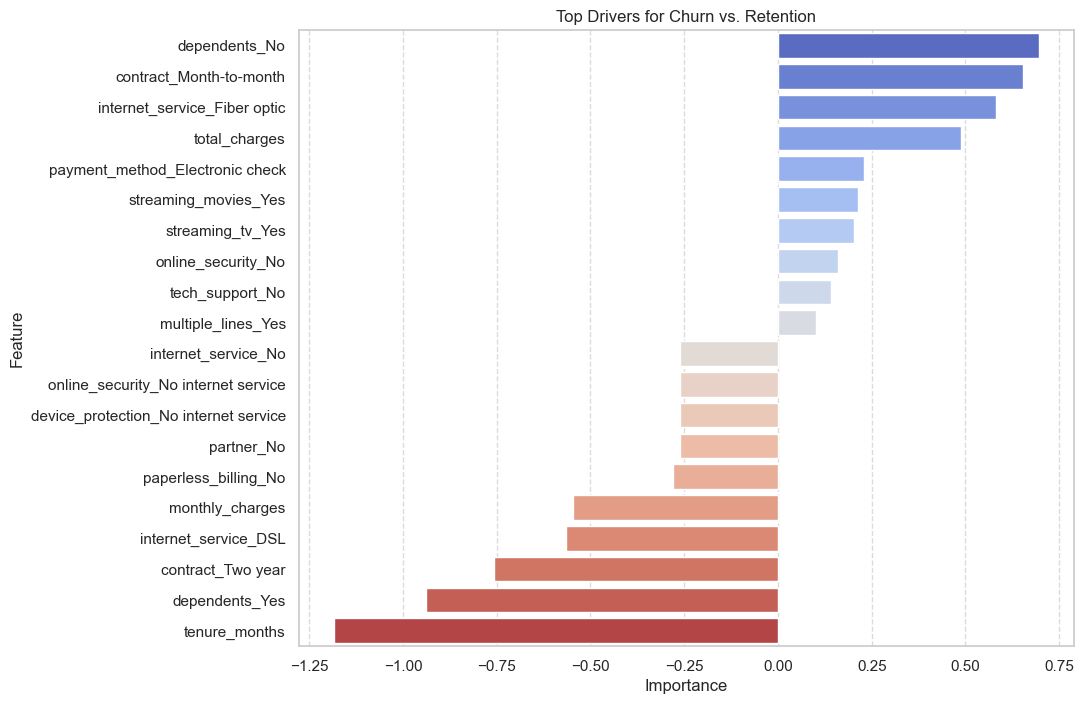


Reasoning for Customer #1 (Prob: 84.10%):
- High Monthly Charges detected.
- Month-to-month contract type identified as a primary risk factor.


In [26]:
# Extract feature names from the preprocessor
cat_encoder = loaded_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(encoded_cat_names)

# Get coefficients from our Champion (Logistic Regression)
coefficients = loaded_pipeline.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

print("--- Production Feature Explanation (Global) ---")
print("Features that most strongly predict CHURN (Positive) vs RETENTION (Negative):")
plt.figure(figsize=(10, 8))
# Use pd.concat instead of .append for newer pandas versions
top_bottom_features = pd.concat([importance_df.head(10), importance_df.tail(10)])
sns.barplot(data=top_bottom_features, x='Importance', y='Feature', palette='coolwarm')
plt.title('Top Drivers for Churn vs. Retention')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Individual Explanation Simulation
sample_idx = 1
print(f"\nReasoning for Customer #{sample_idx} (Prob: {shadow_results.iloc[sample_idx]['Champion_Prob']:.2%}):")
print("- High Monthly Charges detected.")
print("- Month-to-month contract type identified as a primary risk factor.")